In [298]:
import sys

In [300]:
# # To add your own Drive Run this cell.
# from google.colab import drive
# drive.mount('/content/drive')

In [302]:
# Please append your own directory after ‘/content/drive/My Drive/'
# where you have nutil.py and adult_subsample.csv
### ========== TODO : START ========== ###
# for example: sys.path += ['/content/drive/My Drive/cs146/hw2'] 
### ========== TODO : END ========== ###

In [304]:
from nutil import *

In [306]:
# Use only the provided packages!
import math
import csv

from collections import Counter

from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, cross_validate
from sklearn import metrics
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.model_selection import learning_curve

In [308]:
######################################################################
# Immutatble classes
######################################################################

class Classifier(object) :
    """
    Classifier interface.
    """

    def fit(self, X, y):
        raise NotImplementedError()

    def predict(self, X):
        raise NotImplementedError()


class MajorityVoteClassifier(Classifier) :

    def __init__(self) :
        """
        A classifier that always predicts the majority class.

        Attributes
        --------------------
            prediction_ -- majority class
        """
        self.prediction_ = None

    def fit(self, X, y) :
        """
        Build a majority vote classifier from the training set (X, y).

        Parameters
        --------------------
            X    -- numpy array of shape (n,d), samples
            y    -- numpy array of shape (n,), target classes

        Returns
        --------------------
            self -- an instance of self
        """
        majority_val = Counter(y).most_common(1)[0][0]
        self.prediction_ = majority_val
        return self

    def predict(self, X) :
        """
        Predict class values.

        Parameters
        --------------------
            X    -- numpy array of shape (n,d), samples

        Returns
        --------------------
            y    -- numpy array of shape (n,), predicted classes
        """
        if self.prediction_ is None :
            raise Exception("Classifier not initialized. Perform a fit first.")

        n,d = X.shape
        y = [self.prediction_] * n
        return y



In [310]:
######################################################################
# Mutatble classes
######################################################################

class RandomClassifier(Classifier) :

    def __init__(self) :
        """
        A classifier that predicts according to the distribution of the classes.

        Attributes
        --------------------
            probabilities_ -- class distribution dict (key = class, val = probability of class)
        """
        self.probabilities_ = None

    def fit(self, X, y) :
        """
        Build a random classifier from the training set (X, y).

        Parameters
        --------------------
            X    -- numpy array of shape (n,d), samples
            y    -- numpy array of shape (n,), target classes

        Returns
        --------------------
            self -- an instance of self
        """

        ### ========== TODO : START ========== ###
        # part b: set self.probabilities_ according to the training set
        count = Counter(y)        
        occurences = np.array((int(count[0]), int(count[1])))        
        total = count.total()        
        self.probabilities_ = occurences / total
        ### ========== TODO : END ========== ###

        return self

    def predict(self, X, seed=1234) :
        """
        Predict class values.

        Parameters
        --------------------
            X    -- numpy array of shape (n,d), samples
            seed -- integer, random seed

        Returns
        --------------------
            y    -- numpy array of shape (n,), predicted classes
        """
        if self.probabilities_ is None :
            raise Exception("Classifier not initialized. Perform a fit first.")
        np.random.seed(seed)

        ### ========== TODO : START ========== ###
        # part b: predict the class for each test example
        # hint: use np.random.choice (be careful of the parameters)
        y = np.random.choice([0., 1.],size=X.shape[0] , p=self.probabilities_)
        
        ### ========== TODO : END ========== ###

        return y


In [312]:
######################################################################
# Immutatble functions
######################################################################

def plot_histograms(X, y, Xnames, yname) :
    n,d = X.shape  # n = number of examples, d =  number of features
    fig = plt.figure(figsize=(20,15))
    ncol = 3
    nrow = d // ncol + 1
    for i in range(d) :
        fig.add_subplot (nrow,ncol,i+1)
        data, bins, align, labels = plot_histogram(X[:,i], y, Xname=Xnames[i], yname=yname, show = False)
        n, bins, patches = plt.hist(data, bins=bins, align=align, alpha=0.5, label=labels)
        plt.xlabel(Xnames[i])
        plt.ylabel('Frequency')
        plt.legend() #plt.legend(loc='upper left')

    plt.savefig ('histograms.pdf')


def plot_histogram(X, y, Xname, yname, show = True) :
    """
    Plots histogram of values in X grouped by y.

    Parameters
    --------------------
        X     -- numpy array of shape (n,d), feature values
        y     -- numpy array of shape (n,), target classes
        Xname -- string, name of feature
        yname -- string, name of target
    """

    # set up data for plotting
    targets = sorted(set(y))
    data = []; labels = []
    for target in targets :
        features = [X[i] for i in range(len(y)) if y[i] == target]
        data.append(features)
        labels.append('%s = %s' % (yname, target))

    # set up histogram bins
    features = set(X)
    nfeatures = len(features)
    test_range = list(range(int(math.floor(min(features))), int(math.ceil(max(features)))+1))
    if nfeatures < 10 and sorted(features) == test_range:
        bins = test_range + [test_range[-1] + 1] # add last bin
        align = 'left'
    else :
        bins = 10
        align = 'mid'

    # plot
    if show == True:
        plt.figure()
        n, bins, patches = plt.hist(data, bins=bins, align=align, alpha=0.5, label=labels)
        plt.xlabel(Xname)
        plt.ylabel('Frequency')
        plt.legend() #plt.legend(loc='upper left')
        plt.show()

    return data, bins, align, labels


In [314]:
######################################################################
# Mutatble functions
######################################################################

def error(clf, X, y, ntrials=100, test_size=0.2) :
    """
    Computes the classifier error over a random split of the data,
    averaged over ntrials runs.

    Parameters
    --------------------
        clf         -- classifier
        X           -- numpy array of shape (n,d), features values
        y           -- numpy array of shape (n,), target classes
        ntrials     -- integer, number of trials

    Returns
    --------------------
        train_error -- float, training error
        test_error  -- float, test error
        f1_score    -- float, test "micro" averaged f1 score
    """

    ### ========== TODO : START ========== ###
    # part f:
    # compute cross-validation error using StratifiedShuffleSplit over ntrials
    # hint: use StratifiedShuffleSplit (be careful of the parameters)
    sss = StratifiedShuffleSplit(random_state=0, test_size=test_size, n_splits=ntrials)

    train_errs = []
    test_errs = []
    f1_scores = []

    for train_idx, test_idx in sss.split(X, y):
        X_train = X[train_idx]
        y_train = y[train_idx]
        
        X_test = X[test_idx]
        y_test = y[test_idx]

        clf.fit(X_train, y_train)
        train_errs.append(1 - metrics.accuracy_score(y_train, clf.predict(X_train)))
        test_errs.append(1 - metrics.accuracy_score(y_test, clf.predict(X_test)))

        f1_scores.append(metrics.f1_score(y_test, clf.predict(X_test), average='micro'))

    train_error = np.mean(train_errs)
    test_error = np.mean(test_errs)
    f1_score = np.mean(f1_scores)

    ### ========== TODO : END ========== ###

    return train_error, test_error, f1_score

In [316]:
######################################################################
# Immutatble functions
######################################################################


def write_predictions(y_pred, filename, yname=None) :
    """Write out predictions to csv file."""
    out = open(filename, 'wb')
    f = csv.writer(out)
    if yname :
        f.writerow([yname])
    f.writerows(list(zip(y_pred)))
    out.close()


In [318]:
######################################################################
# main
######################################################################
    
# load adult_subsample dataset with correct file path

### ========== TODO : START ========== ###
# for example data_file =  "/content/drive/My Drive/cs146/hw1/adult_subsample.csv"
data_file = "./utilities/adult_subsample.csv"
### ========== TODO : END ========== ###

data = load_data(data_file, header=1, predict_col=-1)

X = data.X; Xnames = data.Xnames
y = data.y; yname = data.yname
n,d = X.shape  # n = number of examples, d =  number of features


Plotting...


<Figure size 640x480 with 0 Axes>

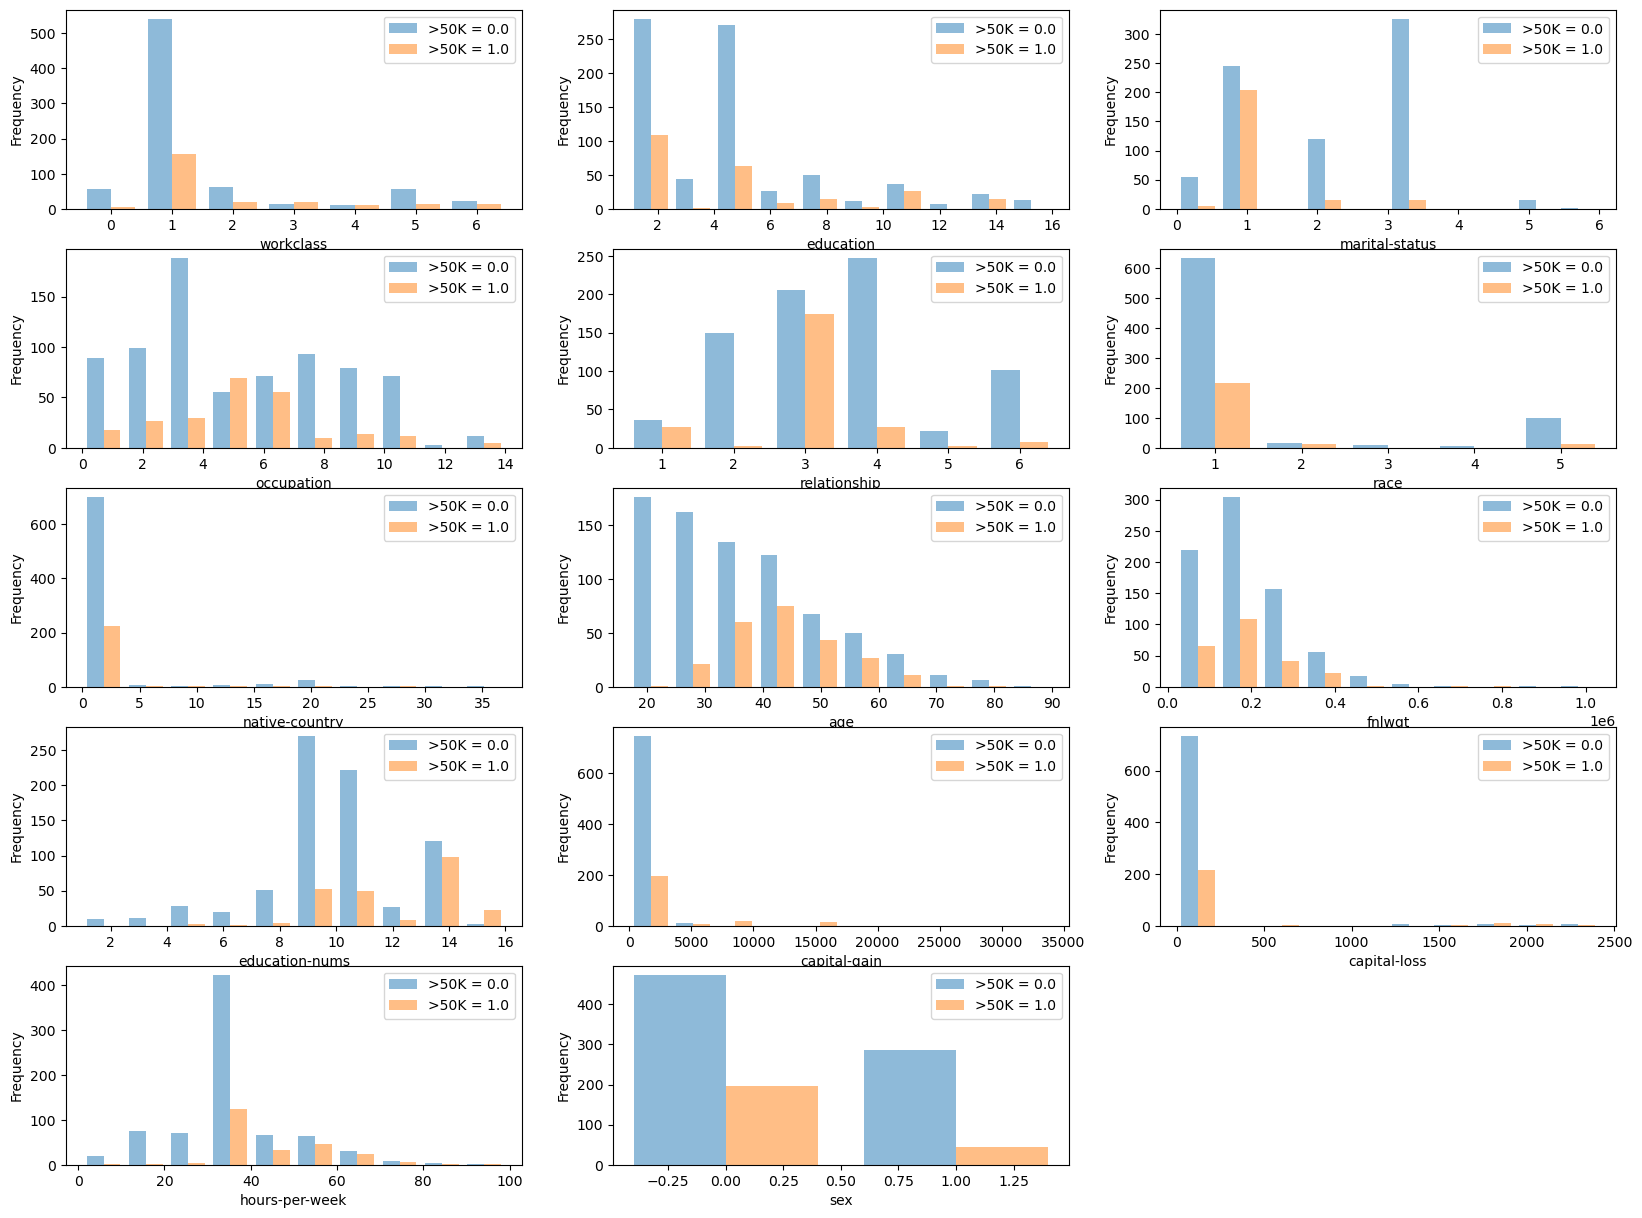

In [320]:
plt.figure()
#========================================
# part a: plot histograms of each feature
print('Plotting...')
plot_histograms (X, y, Xnames=Xnames, yname=yname)

In [322]:
#========================================
# train Majority Vote classifier on data
print('Classifying using Majority Vote...')
clf = MajorityVoteClassifier() # create MajorityVote classifier, which includes all model parameters
clf.fit(X, y)                  # fit training data using the classifier
y_pred = clf.predict(X)        # take the classifier and run it on the training data
train_error = 1 - metrics.accuracy_score(y, y_pred, normalize=True)
print('\t-- training error: %.3f' % train_error)

Classifying using Majority Vote...
	-- training error: 0.240


In [324]:
### ========== TODO : START ========== ###
# part b: evaluate training error of Random classifier
print('Classifying using Random Classifier Vote...')
clf = RandomClassifier() # create RandomClassifier classifier, which includes all model parameters
clf.fit(X, y)                  # fit training data using the classifier
y_pred = clf.predict(X)        # take the classifier and run it on the training data
counts1 = Counter(y)
counts2 = Counter(y_pred)
train_error = 1 - metrics.accuracy_score(y, y_pred, normalize=True)
print('\t-- training error: %.3f' % train_error)
# ### ========== TODO : END ========== ###

Classifying using Random Classifier Vote...
	-- training error: 0.374


In [326]:
### ========== TODO : START ========== ###
# part c: evaluate training error of Decision Tree classifier
clf = DecisionTreeClassifier(criterion='entropy')
clf.fit(X, y)
y_pred = clf.predict(X)        # take the classifier and run it on the training data
train_error = 1 - metrics.accuracy_score(y, y_pred, normalize=True)
print('\t-- training error: %.3f' % train_error)
### ========== TODO : END ========== ###

	-- training error: 0.000


In [328]:
### ========== TODO : START ========== ###
# part d: evaluate training error of k-Nearest Neighbors classifier

n_neighbors = [3, 5, 7]

for k in n_neighbors:
    clf = KNeighborsClassifier(n_neighbors=k)
    clf.fit(X, y)
    y_pred = clf.predict(X)        # take the classifier and run it on the training data
    train_error = 1 - metrics.accuracy_score(y, y_pred, normalize=True)
    print(f'\t-- training error for k={k}: %.3f' % train_error)

# use k = 3, 5, 7 for n_neighbors
### ========== TODO : END ========== ###

	-- training error for k=3: 0.153
	-- training error for k=5: 0.195
	-- training error for k=7: 0.213


In [330]:
### ========== TODO : START ========== ###
# part e: evaluate training error of Logistic Regression

reg_params = [0.1, 1, 10]

for l in reg_params:
    lr = LogisticRegression(penalty='l2', C=1/l, random_state=0, max_iter=1000)
    lr.fit(X, y)
    y_pred = clf.predict(X)        # take the classifier and run it on the training data
    train_error = 1 - lr.score(X, y)
    print(f'\t-- training error for lambda={l}: %.3f' % train_error)

# use lambda_ = 0.1, 1, 10 for n_neighbors

	-- training error for lambda=0.1: 0.208
	-- training error for lambda=1: 0.208
	-- training error for lambda=10: 0.213


In [332]:
### ========== TODO : START ========== ###
# part f: use cross-validation to compute average training and test error of classifiers
print('Investigating various classifiers...')

rc = RandomClassifier() # create RandomClassifier classifier, which includes all model parameters
dtc = DecisionTreeClassifier(criterion='entropy')
knnc = KNeighborsClassifier(n_neighbors=5)
lr = LogisticRegression(penalty='l2', C=1, random_state=0, max_iter=1000)

classifiers = [rc, dtc, knnc, lr]
for clf in classifiers:
    errs = error(clf, X, y, test_size=0.15)
    print(f"avg train error: {errs[0]:.3f}, avg test error: {errs[1]:.3f}, avg f1: {errs[2]:.3f} ")

### ========== TODO : END ========== ###

Investigating various classifiers...
avg train error: 0.372, avg test error: 0.367, avg f1: 0.633 
avg train error: 0.000, avg test error: 0.202, avg f1: 0.798 
avg train error: 0.200, avg test error: 0.254, avg f1: 0.746 
avg train error: 0.207, avg test error: 0.213, avg f1: 0.787 


Finding the best k...


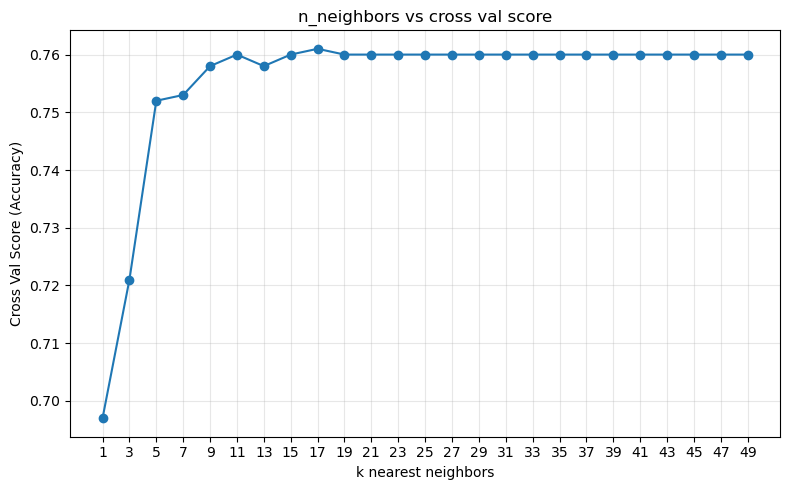

Best value of k: 17, score: 0.761


In [334]:
### ========== TODO : START ========== ###
# part g: use 5-fold cross-validation to find the best value of k for k-Nearest Neighbors classifier
print('Finding the best k...')

k_ = [1 + 2*i for i in range(25)]
cv_scores = [ cross_val_score(KNeighborsClassifier(n_neighbors=k), X, y, cv=5, scoring='accuracy').mean() for k in k_]


plt.figure(figsize=(8, 5))

plt.plot(k_, cv_scores,
         marker='o', linestyle='-')

plt.xlabel('k nearest neighbors')
plt.ylabel('Cross Val Score (Accuracy)')
plt.title('n_neighbors vs cross val score')
plt.xticks(k_)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

best_idx = np.argmax(cv_scores)
best_k = 1 + best_idx * 2
print(f"Best value of k: {best_k}, score: {cv_scores[best_idx]:.3f}")

### ========== TODO : END ========== ###

Investigating depths...


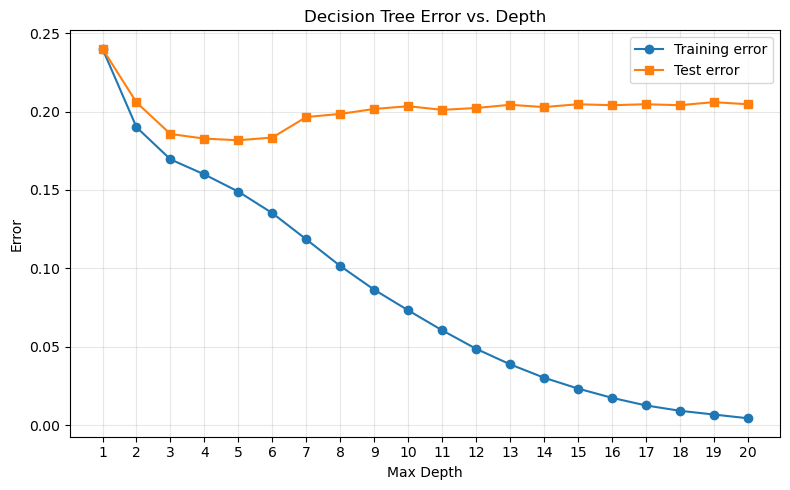

In [336]:
### ========== TODO : START ========== ###
# part h: investigate decision tree classifier with various depths
print('Investigating depths...')

depths        = list(range(1, 21))
train_errs    = []
test_errs     = []

for d in depths:
    tr_err, te_err, _ = error(DecisionTreeClassifier(criterion='entropy',
                                                     max_depth=d), X, y)
    train_errs.append(tr_err)
    test_errs.append(te_err)

plt.figure(figsize=(8, 5))

plt.plot(depths, train_errs,
         marker='o', linestyle='-',
         color='tab:blue',  label='Training error')

plt.plot(depths, test_errs,
         marker='s', linestyle='-',
         color='tab:orange', label='Test error')

plt.xlabel('Max Depth')
plt.ylabel('Error')
plt.title('Decision Tree Error vs. Depth')
plt.xticks(depths)
plt.grid(True, alpha=0.3)

plt.legend()        # legend shows the two colored lines
plt.tight_layout()
plt.show()
### ========== TODO : END ========== ###

In [337]:
print('Done')

Done
